## LangChain

대규모 언어모델(LLM)을 더 쉽게 활용할 수 있도록 도와주는 **프레임워크**

**프롬프트 관리, 메모리, 외부 도구(tool) 연동, 문서 검색(RAG)** 등을 체계적으로 구성할 수 있음

실제로는 **검색, 분석, 정보 정리** 등 여러 절차가 백그라운드에서 함께 작동해야 더 정확하고 풍부한 답변을 얻을 수 있음

이러한 여러 단계를 **하나의 체계적인 구조로 묶어주는 프레임워크**임  
즉, LLM이 단독으로 모든 일을 처리하는 대신
"사용자 입력 -> 관련 정보 검색 -> 분석 및 요약 -> 결과 생성" 과 같은  
복잡한 흐름을 하나의 **체인**으로 자동화할 수 있음

---

설치

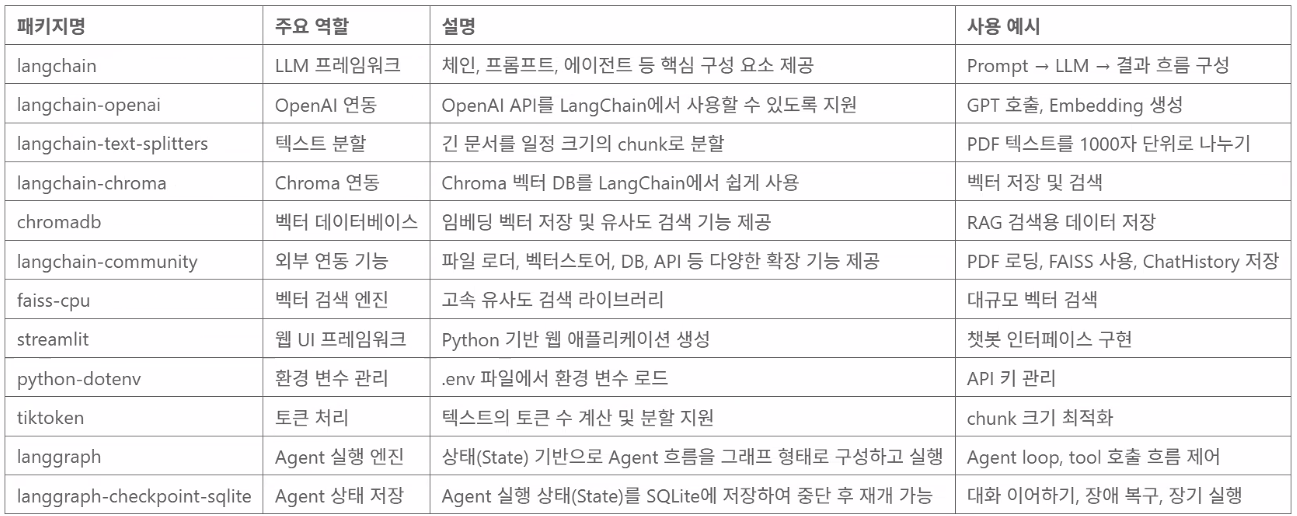





In [1]:
%pip install langchain langchain-openai langchain-text-splitters langchain-chroma chromadb streamlit faiss-cpu python-dotenv tiktoken langchain-community  langgraph langgraph-checkpoint-sqlite

Note: you may need to restart the kernel to use updated packages.


---

API 키 없이 웹 검색을 LLM에 연결해주는 간단한 검색 도구로 아래와 같이 제공함

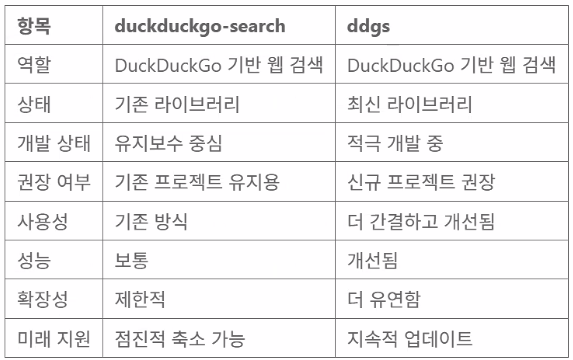

- 신규 프로젝트 이므로 ddgs를 설치

In [2]:
%pip install ddgs

Note: you may need to restart the kernel to use updated packages.


---

1. from langchain_openai import ChatOpenAI
    - OpenAI API를 Langchain에서 사용할 수 있게 해주는 클래스
    - 내부적으로 OpenAI의 GPT 모델을 호출하는 역할

2. from langchain_core.prompts import PromptTemplate
    - 문자열 기반 프롬프트를 템플릿 형태로 관리하는 도구
    - {변수} 형태로 값을 받아 동적으로 문장 생성 가능

3. from langchain_core.output_parsers import StrOutputParser
    - LLM 응답 객체에서 텍스트(content만 추출
    - LangChain의 출력 객체 -> 문자열로 반환

In [3]:
# OpenAI API를 LangChain에서 쉽게 쓸 수 있도록 해주는 래퍼 모듈
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
load_dotenv()

# LCEL 방식: 파이프라인 형태로 선언
llm = ChatOpenAI(model="gpt-4.1-nano")

# {topic} -> 변수 자리, 실행 시 값이 들어가면서 문장이 완성됨
prompt = PromptTemplate.from_template("'{topic}' 주제에 대해 한 문장으로 설명해줘.")

output_str = StrOutputParser()      # 결과 객체에서 텍스트(content)만 깔끔하게 추출해 문자열로 변환

# LangChain Expression Language(LCEL) 표현
# | : 파이프 연산자로 데이터 흐름을 연결
# 프롬프트 -> LLM -> 출력
# PromptTemplate -> ChatOpenAI -> StrOutputParser
chain = prompt | llm | output_str

# chain.invoke(): 전체 파이프라인을 한 번 실행하는 메서드
result = chain.invoke({"topic" : "LangChain"})

print(result)

c:\github\siat-study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LangChain은 자연어 처리 애플리케이션에서 언어 모델을 쉽게 통합하고 활용할 수 있도록 돕는 프레임워크입니다.


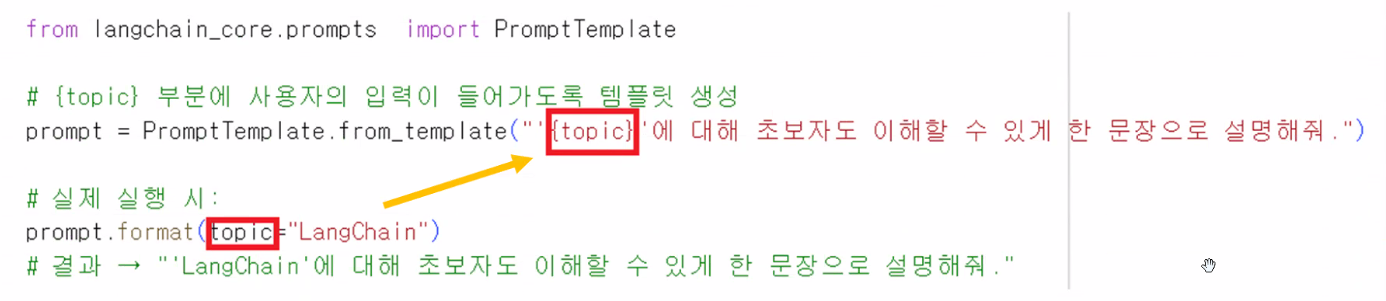

chain.invoke()가 실행되면 입력 딕셔너리의 "topic"값이 PromptTemplate의 {topic} 변수에 바인딩되어 최종 프롬프트 문자열이 생성됨

---

Agent 예제

1. from langchain.agents import create_agent
    - Agent를 생성하는 함수
    - LLM + tool들을 결합하여 "판단 + 실행" 구조를 만듬

2. from langchain.tools import tool
    - 일반 파이썬 함수를 Agent가 사용할 수 있는 tool로 변환함
    - 함수 설명(docstring)이 매우 중요함. Agent가 선택 기준으로 사용

In [4]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv
from datetime import datetime   # 현재 날짜/시간을 가져오기 위한 파이썬 표준 라이브러리
import pytz                     # 타임존 처리를 위한 라이브러리

load_dotenv()

llm = ChatOpenAI(model="gpt-4.1-nano")


# @tool 데코레이터: 이 함수는 Agent가 호출 가능한 도구가 됨
@tool   # timezone 파라미터는 LLM이 tool을 호출할 때 timezone 값을 생성해서 전달함
def get_current_time(timezone: str = "Asia/Seoul"):
    """타임존의 현재 날짜와 시간을 'YYYY-MM-DD HH:MM:SS' 형식으로 반환"""
    try:
        tz = pytz.timezone(timezone)
        return datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S") + f" {timezone}"
    except Exception as e:
        return f"시간 가져오기 오류: {e}"
    

@tool
def explain_topic(topic: str) -> str:
    """주제를 한 문장으로 간단히 설명함"""
    return f"{topic}은(는) AI 애플리케이션 개발에 자주 활용되는 개념입니다."


agent = create_agent(
    model=llm,
    tools=[get_current_time, explain_topic],
    system_prompt="당신은 필요한 경우 도구를 사용해 정확하게 답변하는 도우미입니다."
)


result = agent.invoke(
    {
        "messages" : [
            {"role" : "user", "content" : "지금 시간이랑 LangChain 설명을 같이 알려줘."}
        ]
    }
)

print(result)

{'messages': [HumanMessage(content='지금 시간이랑 LangChain 설명을 같이 알려줘.', additional_kwargs={}, response_metadata={}, id='176c53cf-75eb-4224-a2b1-b1d2f677c77d'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 129, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_36707952b5', 'id': 'chatcmpl-DMPo4PkG1CulT6q8jPk72wzEJAW0E', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d18a2-6121-70a1-98f1-e2f2a112cb95-0', tool_calls=[{'name': 'get_current_time', 'args': {}, 'id': 'call_g461Bk0PeVwTeBzyBUnVLkTK', 'type': 'tool_call'}, {'name': 'explain_topic', 'args': {'topic': 'LangChain'}, 'id': 'call_G8nxKO

In [5]:
final_text = result["messages"][-1].content
print(final_text)

현재 시간은 2026년 3월 23일 11시 59분 49초이고, 한국 시간(Asia/Seoul) 기준입니다. 

LangChain은 AI 애플리케이션 개발에 자주 활용되는 개념으로, 다양한 언어 모델과 도구를 연결하여 복잡한 작업을 수행하도록 하는 프레임워크입니다.


---

웹 서치

- DDGS는 DuckDuckGo 검색 엔진을 Python에서 사용할 수 있게 해주는 라이브러리
- DDGS() 호출
    - DDGS는 내부적으로 네트워크 연결, 세션, 리소스를 사용
    - with를 사용해서 연결 자동 종료, 메모리 누수 방지를 할 수 있음
    - 예) 검색 결과 한 개 형태

        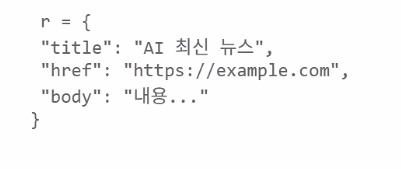

In [6]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv
from ddgs import DDGS

load_dotenv()

llm = ChatOpenAI(model="gpt-4.1-nano")

import os
os.environ["SSL_CERT_FILE"] = r"C:\cert\cacert.pem"
os.environ["CURL_CA_BUNDLE"] = r"C:\cert\cacert.pem"


# ddgs 웹 검색 tool
@tool
def web_search(query: str) -> str:
    """웹에서 최신 정보를 검색합니다."""

    # DuckDuckGo 검색 실행
    try:
        with DDGS() as ddgs:
            results = ddgs.text(query, max_results=3) # max_results=3 -> 상위 3개 결과

            if not results:
                return "검색 결과가 없습니다."
            
            output = []
            for r in results:
                output.append(f"{r['title']} - {r['href']}")

            return "\n".join(output)

    except Exception as e:
        return f"검색 오류: {e}"
    

# Agent 생성
agent = create_agent(
    model=llm,
    tools=[web_search],
    system_prompt="최신 정보가 필요하면 반드시 web_search 도구를 사용하세요."
)

result = agent.invoke(
    {
        "messages":[
            {"role" : "user", "content" : "2026년 3월 최신 기술 3개만 알려줘. 100자 내외로"}
        ]
    }
)

print(result["messages"][-1].content)

2026년 3월 기준으로 주목받는 최신 기술은 다음과 같습니다:
1. 인공지능 AI 기술의 급진적 발전
2. 성과 중심의 혁신 기술 트렌드
3. 차세대 전략 기술(가트너 선정 10대 트렌드)





---

&nbsp; &nbsp; 1. 모델 호출

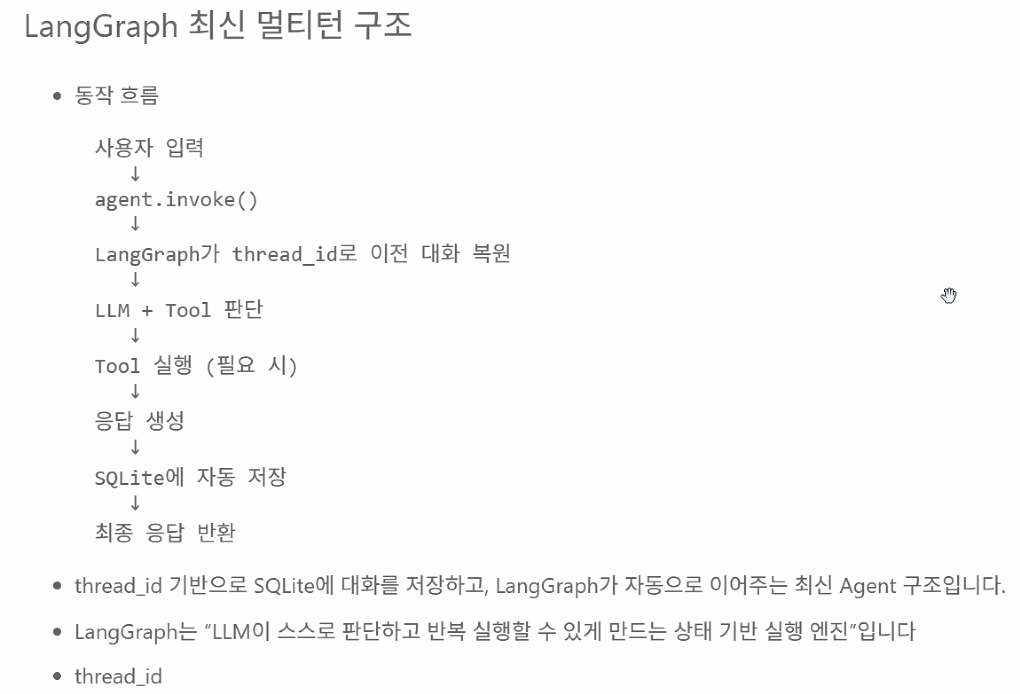

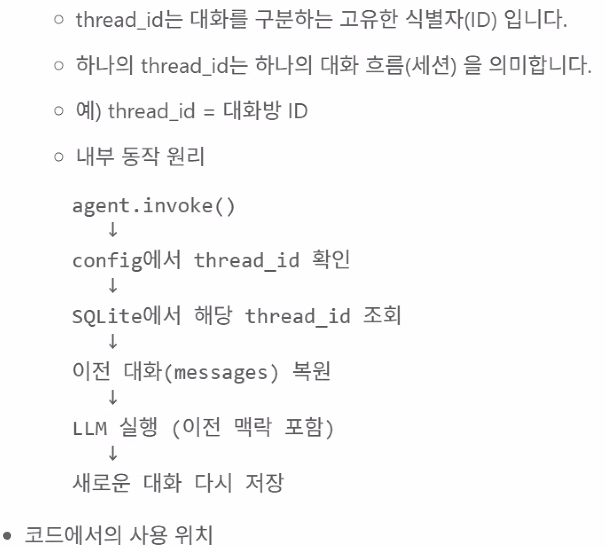

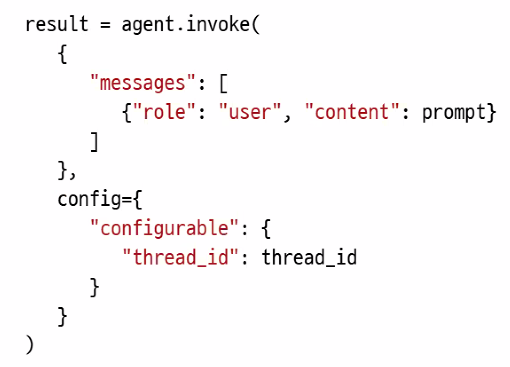